# Python I Module: Solving Initial Value Problems with solve_ivp

## Why Are We Learning This?
Many chemical reactor design problems cannot be solved analytically. Examples include some PFR and batch reactor design problems, many non-isothermal reactor problems, and most problems involving multiple reactions.

The goal of this module is to learn a workflow that can be applied throughout the remainder of the course.

## Learning Objectives
- Review the use of solve_ivp from CBE 2345
- Write a system of ODEs
- Create a Python function representing the ODEs
- Solve an IVP using solve_ivp
- Extract results from the solution object
- Plot results using Matplotlib
- Interpret numerical solutions

Let's start by reviewing solve_ivp. We can apply this to the the series reactions A → B → C with elementary kinetics.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## Step 1: Define Parameters and ODEs

Let's carry these reactions out in the liquid phase in a beaker (e.g., a bench top sized batch reactor). The rate constants k1 and k2 are 0.50 and 0.20 hr^-1. The reaction can be assumed to be constant volume since we're carrying it out in the liquid phase.

In [ ]:
k1 = 0.50  # 1/hr
k2 = 0.20  # 1/hr

def reactor_odes(t, C):
    CA, CB, CC = C

    dCAdt = -k1 * CA
    dCBdt = k1 * CA - k2 * CB
    dCCdt = k2 * CB

    return [dCAdt, dCBdt, dCCdt]

## Step 2: Define Initial Conditions

Let's carry out the reaction for initial conditions of CA, CB, and CC of 2.0 M, 0.0 M, and 0.0 M, respectively.

In [ ]:
C0 = [2.0, 0.0, 0.0]

## Step 3: Define Time Span

This is really up to you. Over what time interval do you want to observe the predicted concentrations?

In [ ]:
t_start = 0
t_end = 15
t_eval = np.linspace(t_start, t_end, 200)

## Step 4: Solve the ODE System

In [ ]:
solution = solve_ivp(reactor_odes,[t_start, t_end],C0,t_eval=t_eval)

## Step 5: Extract Results

In [ ]:
t = solution.t
CA = solution.y[0]
CB = solution.y[1]
CC = solution.y[2]

## Step 6: Plot the Results

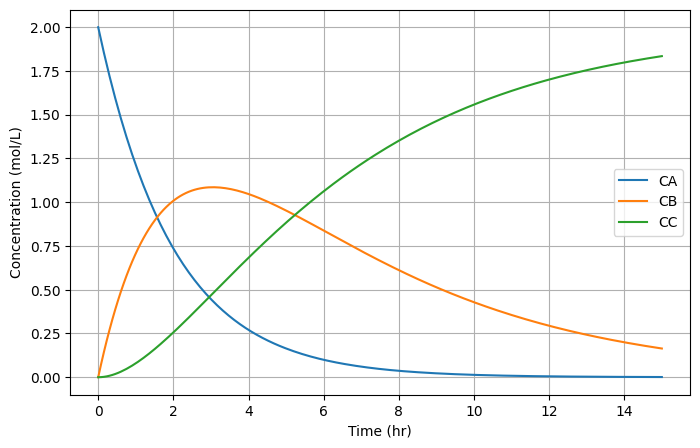

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(t, CA, label="CA")
plt.plot(t, CB, label="CB")
plt.plot(t, CC, label="CC")
plt.xlabel("Time (hr)")
plt.ylabel("Concentration (mol/L)")
plt.legend()
plt.grid()
plt.show()

## Interpreting the Results
- CA should decrease with time.
- CC should increase with time.
- CB should rise, reach a maximum, and then decrease.

## Common Student Errors
1. Using `def reactor_odes(C,t)` instead of `def reactor_odes(t,C)` for solve_ivp.
2. Forgetting to specify initial conditions.
3. Plotting the solution object rather than its contents.
4. Returning the wrong number of differential equations.
5. Syntax errors

## Challenge Problem
Modify the code so that the reaction A → B follows second-order kinetics:

-rA = k CA^2

Questions:
1. How does the concentration profile change?
2. Does A disappear faster or slower?
3. How does the shape compare with first-order kinetics?

Add your answer here:

# Now let's apply solve_ivp to the "Fogler P10-12" in class activity

## Problem statement

The gas-phase reaction 2A -> B is carried out over a catalyst in a PFR.

Rate law:

$$-r_A = \frac{k_{PA}^2}{(1 + K_AP_A + K_BP_B)^2}$$

Parameters: $$k = 1250, K_A = 4, K_B = 13$$

Feed conditions: FA0 = 2 mol/s, PA0 = 2 atm, pure A feed.

## Step 1: Write the Mole Balance

For a PFR:

$$\frac{dX}{dV} = \frac{-r_A}{F_{A0}}$$

## Step 2: Partial Pressures as Functions of Conversion

$$P_A = \frac{P_{A0}(1-X)}{1-\frac{X}{2}}$$

$$P_B = \frac{0.5P_{A0}X}{1-\frac{X}{2}}$$

In [ ]:
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar

In [ ]:
k = 1250
KA = 4
KB = 13
FA0 = 2
PA0 = 2

In [ ]:
def rate(X):
    PA = PA0*(1-X)/(1-X/2)
    PB = 0.5*PA0*X/(1-X/2)
    rA = -k*PA**2/(1 + KA*PA + KB*PB)**2
    return rA

def pfr_ode(V,y):
    X = y[0]
    return [(-rate(X))/FA0]

## Example 1: Conversion in a 2-L PFR

In [ ]:
sol = solve_ivp(pfr_ode,[0,2],[0],t_eval=np.linspace(0,2,200))
X_final = sol.y[0,-1]
print("Conversion at 2 L =", X_final)

Conversion at 2 L = 0.9669798663297081


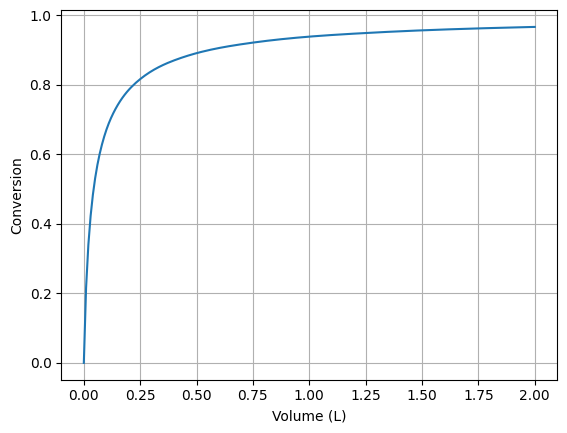

In [ ]:
plt.plot(sol.t,sol.y[0])
plt.xlabel("Volume (L)")
plt.ylabel("Conversion")
plt.grid()
plt.show()

## Example 2: Conversion in a 1-L PFR

In [ ]:
sol1 = solve_ivp(pfr_ode,[0,1],[0],t_eval=np.linspace(0,1,200))
print("Conversion at 1 L =", sol1.y[0,-1])

Conversion at 1 L = 0.9389746099457197


## Example 3: No Catalyst Case

In [ ]:
k_nc = 1

def rate_no_cat(X):
    PA = PA0*(1-X)/(1-X/2)
    return -k_nc*PA**2

def pfr_ode_no_cat(V,y):
    return [(-rate_no_cat(y[0]))/FA0]

sol_nc = solve_ivp(pfr_ode_no_cat,[0,1],[0],t_eval=np.linspace(0,1,200))
print("1 L PFR without catalyst, X =", sol_nc.y[0,-1])

1 L PFR without catalyst, X = 0.7992079329592


## Example 4: Volume and Catalyst Needed for 90% Conversion

In [ ]:
target = 0.90

def objective(Vf):
    s = solve_ivp(pfr_ode,[0,Vf],[0],t_eval=[Vf])
    return s.y[0,-1] - target

root = root_scalar(objective, bracket=[0.001,50])
Vreq = root.root
print("Required reactor volume (L)=",Vreq)

rho_b = 500 # kg/m^3
W = (Vreq/1000)*rho_b
print("Catalyst mass (kg)=",W)

Required reactor volume (L)= 0.5538825456227875
Catalyst mass (kg)= 0.27694127281139375


## Example 5: Catalyst Cost

In [ ]:
price_per_g = 350/50
cost = W*1000*price_per_g
print("Estimated catalyst cost ($)=",cost)

Estimated catalyst cost ($)= 1938.5889096797562


## Challenge Problem

Apply this workflow to Practice Problems 3 and 4.